In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('dane/fra_perfumes.csv')
print(f"Rozmiar początkowy bazy: {df.shape}")

Rozmiar początkowy bazy: (70103, 8)


In [43]:
df.head()

,Name,Gender,Rating Value,Rating Count,Main Accords,Perfumers,Description,url
0,9am Afnanfor women,for women,3.73,174,"['citrus', 'musky', 'woody', 'aromatic', 'warm...",[],9ambyAfnanis a fragrance for women. Top notes ...,https://www.fragrantica.com/perfume/Afnan/9am-...
1,9am Dive Afnanfor women and men,for women and men,4.29,842,"['fruity', 'woody', 'green', 'warm spicy', 'ar...",[],9am DivebyAfnanis a Aromatic Aquatic fragrance...,https://www.fragrantica.com/perfume/Afnan/9am-...
2,9am pour Femme Afnanfor women,for women,4.00,68,"['fruity', 'musky', 'amber', 'citrus', 'powder...",[],9am pour FemmebyAfnanis a Amber fragrance for ...,https://www.fragrantica.com/perfume/Afnan/9am-...
3,9pm Afnanfor men,for men,4.50,"6,865","['vanilla', 'amber', 'warm spicy', 'cinnamon',...",[],9pmbyAfnanis a Amber Vanilla fragrance for men...,https://www.fragrantica.com/perfume/Afnan/9pm-...
4,9pm pour Femme Afnanfor women,for women,3.49,63,"['woody', 'aromatic', 'rose', 'fruity', 'powde...",[],9pm pour FemmebyAfnanis a Amber Floral fragran...,https://www.fragrantica.com/perfume/Afnan/9pm-...


In [44]:
df = df.dropna(subset=['Name', 'Description'])

In [45]:
df['Rating Count'] = pd.to_numeric(df['Rating Count'], errors='coerce')
df['Rating Value'] = pd.to_numeric(df['Rating Value'], errors='coerce')
df = df.dropna(subset=['Rating Count', 'Rating Value'])

In [46]:
MIN_RATINGS = 50
df_cleaned = df[df['Rating Count'] >= MIN_RATINGS].copy()
df_cleaned = df_cleaned.reset_index(drop=True)

In [47]:
print(f"Rozmiar bazy po czyszczeniu (min. {MIN_RATINGS} ocen): {df_cleaned.shape}")

Rozmiar bazy po czyszczeniu (min. 50 ocen): (21704, 8)


In [48]:
import ast 

def clean_accords(accord_string):
    try:
        accords_list = ast.literal_eval(accord_string)
        return ", ".join(accords_list)
    except:
        return "" 

In [49]:
df_cleaned['Brand'] = df_cleaned['url'].str.extract(r'/perfume/([^/]+)/')
df_cleaned['Brand'] = df_cleaned['Brand'].str.replace('-', ' ')

df_cleaned['Perfume_ID'] = df_cleaned['url'].str.extract(r'-(\d+)\.html')

df_cleaned['Description'] = df_cleaned['Description'].str.replace(r'([a-zA-Z0-9])by([A-Z])', r'\1 by \2', regex=True)
df_cleaned['Description'] = df_cleaned['Description'].str.replace(r'([a-zA-Z])is a ', r'\1 is a ', regex=True)

df_cleaned['Clean_Accords'] = df_cleaned['Main Accords'].apply(clean_accords)

df_cleaned['Semantic_Text'] = df_cleaned['Description'] + " Main accords: " + df_cleaned['Clean_Accords'] + "."

print("Przykładowe wyciągnięte Marki i ID")
print(df_cleaned[['Brand', 'Perfume_ID', 'Clean_Accords']].head(3).to_string())

print("\nTekst Semantyczny (Semantic_Text)")
print(df_cleaned['Semantic_Text'].iloc[0])

Przykładowe wyciągnięte Marki i ID
   Brand Perfume_ID                                                                              Clean_Accords
0  Afnan      70706  citrus, musky, woody, aromatic, warm spicy, lavender, mossy, fruity, earthy, white floral
1  Afnan      78611  fruity, woody, green, warm spicy, aromatic, citrus, fresh, fresh spicy, soft spicy, amber
2  Afnan      78541                         fruity, musky, amber, citrus, powdery, sweet, animalic, soft spicy

Tekst Semantyczny (Semantic_Text)
9am by Afnan is a fragrance for women. Top notes are Lemon, Mandarin Orange, Cardamom and Pink Pepper; middle notes are Lavender, Green Apple, Orange Blossom and Rose; base notes are Musk, Moss, Cedar and Patchouli. Main accords: citrus, musky, woody, aromatic, warm spicy, lavender, mossy, fruity, earthy, white floral.


In [50]:
df_cleaned.head()

,Name,Gender,Rating Value,Rating Count,Main Accords,Perfumers,Description,url,Brand,Perfume_ID,Clean_Accords,Semantic_Text
0,9am Afnanfor women,for women,3.73,174.0,"['citrus', 'musky', 'woody', 'aromatic', 'warm...",[],9am by Afnan is a fragrance for women. Top not...,https://www.fragrantica.com/perfume/Afnan/9am-...,Afnan,70706,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...
1,9am Dive Afnanfor women and men,for women and men,4.29,842.0,"['fruity', 'woody', 'green', 'warm spicy', 'ar...",[],9am Dive by Afnan is a Aromatic Aquatic fragra...,https://www.fragrantica.com/perfume/Afnan/9am-...,Afnan,78611,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...
2,9am pour Femme Afnanfor women,for women,4.00,68.0,"['fruity', 'musky', 'amber', 'citrus', 'powder...",[],9am pour Femme by Afnan is a Amber fragrance f...,https://www.fragrantica.com/perfume/Afnan/9am-...,Afnan,78541,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...
3,9pm pour Femme Afnanfor women,for women,3.49,63.0,"['woody', 'aromatic', 'rose', 'fruity', 'powde...",[],9pm pour Femme by Afnan is a Amber Floral frag...,https://www.fragrantica.com/perfume/Afnan/9pm-...,Afnan,78544,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...
4,Black Oudh Al Haramain Perfumesfor women and men,for women and men,4.12,113.0,"['woody', 'powdery', 'musky', 'amber', 'patcho...",[],Black Oudh by Al Haramain Perfumes is a Amber ...,https://www.fragrantica.com/perfume/Al-Haramai...,Al Haramain Perfumes,36596,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...


In [51]:
def extract_clean_name(row):
    full_name = str(row['Name']).strip()
    gender_val = str(row['Gender']).strip()
    brand_val = str(row['Brand']).strip()
    
    if full_name.endswith(gender_val):
        full_name = full_name[:-len(gender_val)].strip()
        
    if full_name.lower().endswith(brand_val.lower()):
        full_name = full_name[:-len(brand_val)].strip()
        
    return full_name

In [52]:
df_cleaned['Clean_Name'] = df_cleaned.apply(extract_clean_name, axis=1)

df_cleaned['Semantic_Text'] = "Perfume: " + df_cleaned['Clean_Name'] + " by " + df_cleaned['Brand'] + ". " + df_cleaned['Description'] + " Main accords: " + df_cleaned['Clean_Accords'] + "."

print("Porównanie starej nazwy i nowej, czystej nazwy")
print(df_cleaned[['Name', 'Brand', 'Gender', 'Clean_Name']].head(5).to_string())

Porównanie starej nazwy i nowej, czystej nazwy
                                               Name                 Brand             Gender      Clean_Name
0                                9am Afnanfor women                 Afnan          for women             9am
1                   9am Dive Afnanfor women and men                 Afnan  for women and men        9am Dive
2                     9am pour Femme Afnanfor women                 Afnan          for women  9am pour Femme
3                     9pm pour Femme Afnanfor women                 Afnan          for women  9pm pour Femme
4  Black Oudh Al Haramain Perfumesfor women and men  Al Haramain Perfumes  for women and men      Black Oudh


In [53]:
df_cleaned = df_cleaned.drop(columns=['Name'])
df_cleaned = df_cleaned.rename(columns={'Clean_Name': 'Name'})
new_order = [
    'Perfume_ID', 'Name', 'Brand', 'Gender', 'Rating Value', 'Rating Count', 
    'Clean_Accords', 'Description', 'Semantic_Text', 'url', 'Main Accords'
]

df_cleaned = df_cleaned[new_order]

df_cleaned.head()

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm..."
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar..."
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder..."
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde..."
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho..."


STATYSTYKI OPISOWE
       Rating Value  Rating Count
count  21704.000000  21704.000000
mean       3.962623    232.283450
std        0.267869    211.523466
min        1.420000     50.000000
25%        3.790000     83.000000
50%        3.970000    147.000000
75%        4.140000    301.000000
max        4.830000    999.000000


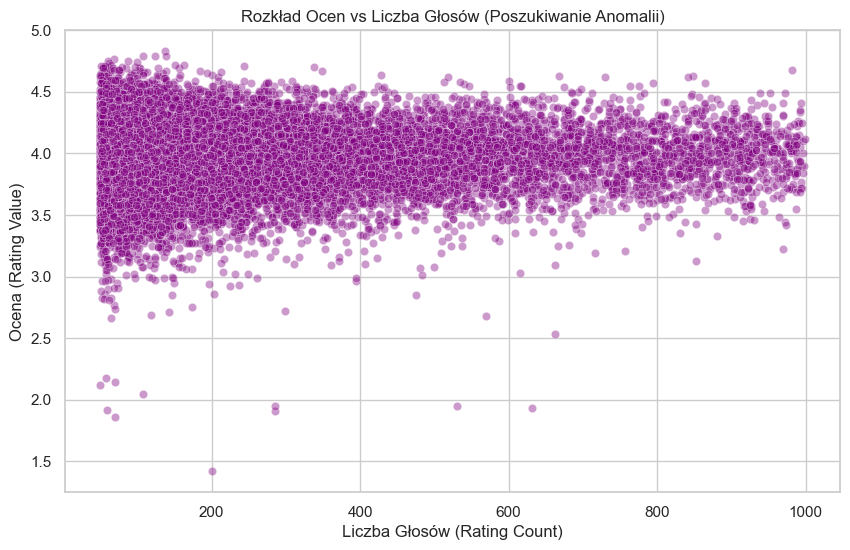

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("STATYSTYKI OPISOWE")
print(df_cleaned[['Rating Value', 'Rating Count']].describe())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Rating Count', y='Rating Value', alpha=0.4, color='purple')
plt.title('Rozkład Ocen vs Liczba Głosów (Poszukiwanie Anomalii)')
plt.xlabel('Liczba Głosów (Rating Count)')
plt.ylabel('Ocena (Rating Value)')
plt.show()


In [55]:
import pandas as pd
from IPython.display import display

hate_bombing = df_cleaned[(df_cleaned['Rating Value'] < 2.6) & (df_cleaned['Rating Count'] >= 50)]

print(f"Znaleziono potencjalny Hate-Bombing ({len(hate_bombing)} rekordów)")

display(hate_bombing[['Name', 'Brand', 'Rating Value', 'Rating Count']])

indexes_to_drop = hate_bombing.index
df_cleaned = df_cleaned.drop(indexes_to_drop).reset_index(drop=True)

print(f"\nUsunięto sztucznie zaniżone oceny. Rozmiar czystej bazy: {df_cleaned.shape}")

Znaleziono potencjalny Hate-Bombing (12 rekordów)


,Name,Brand,Rating Value,Rating Count
4276,Classique Pride 2023,Jean Paul Gaultier,1.91,285.0
4277,Classique Pride 2024,Jean Paul Gaultier,1.86,70.0
4316,Le Male Pride 2023,Jean Paul Gaultier,1.95,531.0
4317,Le Male Pride 2024,Jean Paul Gaultier,1.95,285.0
4318,Le Mâle Pride Collector,Jean Paul Gaultier,1.93,632.0
4319,Le Male Pride Edition,Jean Paul Gaultier,2.53,662.0
7116,Ralph Pride Edition,Ralph Lauren,2.12,50.0
8444,Accento Overdose Pride Edition,Xerjoff,1.42,201.0
12405,Dirty Rainbow BORNTOSTANDOUT®,BORNTOSTANDOUT,2.14,70.0
16419,Sombre,Strangers Parfumerie,2.18,57.0



Usunięto sztucznie zaniżone oceny. Rozmiar czystej bazy: (21692, 11)


In [56]:
df_cleaned.describe()

,Rating Value,Rating Count
count,21692.000000,21692.000000
mean,3.963711,232.273234
std,0.263856,211.516313
min,2.660000,50.000000
25%,3.790000,83.000000
50%,3.970000,147.000000
75%,4.140000,301.000000
max,4.830000,999.000000


In [57]:
import os

folder_path = 'dane'
file_path = os.path.join(folder_path, 'cleaned_data.csv')

df_cleaned.to_csv(file_path, index=False, encoding='utf-8')

print(f"Zapisano wyczyszczoną bazę ({df_cleaned.shape[0]} rekordów) do pliku: {file_path}")

Zapisano wyczyszczoną bazę (21692 rekordów) do pliku: dane\cleaned_data.csv


In [ ]:
import os

os.makedirs('modele', exist_ok=True)
df_cleaned.to_pickle('modele/final_perfume_database.pkl')

print("Baza zapisana pomyślnie! Rozmiar:", df_cleaned.shape)

Baza zapisana pomyślnie! Rozmiar: (21692, 11)


In [ ]:
import os
import numpy as np
from sklearn.decomposition import PCA

current_df = df_cleaned 

print("Wyliczam współrzędne PCA_X oraz PCA_Y dla interfejsu...")

X_matrix = np.array(current_df['Embedding'].tolist())

pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_matrix)

current_df['PCA_X'] = coords[:, 0]
current_df['PCA_Y'] = coords[:, 1]

if 'Cluster_Name' not in current_df.columns:
    current_df['Cluster_Name'] = "Główna Galaktyka"

os.makedirs('modele', exist_ok=True)
current_df.to_pickle('modele/final_perfume_database.pkl')

print("Baza nadpisana! Twoje kolumny to teraz:")
print(current_df.columns.tolist())

Wyliczam współrzędne PCA_X oraz PCA_Y dla interfejsu...


KeyError: 'Embedding'

In [ ]:
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer

if 'Embedding' not in df_cleaned.columns:
    print("Brak kolumny 'Embedding'. Uruchamiam model SBERT (to zajmie chwilę)...")
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    embeddings = model.encode(df_cleaned['Semantic_Text'].tolist(), show_progress_bar=True)
    df_cleaned['Embedding'] = list(embeddings)
    print("Wektory wygenerowane pomyślnie!")

X_matrix = np.array(df_cleaned['Embedding'].tolist())

print("Wyliczam współrzędne PCA_X oraz PCA_Y dla mapy 2D...")
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_matrix)
df_cleaned['PCA_X'] = coords[:, 0]
df_cleaned['PCA_Y'] = coords[:, 1]

if 'Cluster_Name' not in df_cleaned.columns:
    print("Brak klastrów. Uruchamiam K-Means dla 5 grup...")
    kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_matrix)

    cluster_names = {
        0: "Ciężkie-Wieczorowe",
        1: "Świeże-Cytrusowe",
        2: "Kwiatowo-Owocowe",
        3: "Mroczne-Drzewne",
        4: "Orientalno-Przyprawowe"
    }
    df_cleaned['Cluster_Name'] = [cluster_names[label] for label in labels]

os.makedirs('modele', exist_ok=True)
df_cleaned.to_pickle('modele/final_perfume_database.pkl')

print("SUKCES! Baza jest gotowa i zapisana. Posiada następujące kolumny:")
print(df_cleaned.columns.tolist())

Brak kolumny 'Embedding'. Uruchamiam model SBERT (to zajmie chwilę)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/678 [00:00<?, ?it/s]

Wektory wygenerowane pomyślnie!
Wyliczam współrzędne PCA_X oraz PCA_Y dla mapy 2D...
Brak klastrów. Uruchamiam K-Means dla 5 grup...
SUKCES! Baza jest gotowa i zapisana. Posiada następujące kolumny:
['Perfume_ID', 'Name', 'Brand', 'Gender', 'Rating Value', 'Rating Count', 'Clean_Accords', 'Description', 'Semantic_Text', 'url', 'Main Accords', 'Embedding', 'PCA_X', 'PCA_Y', 'Cluster_Name']
